# Wine Quality Dataset - Complete EDA & R3 Diagnostic
### Risk-Aware Dynamic Model Router (R3) - Benchmark Suite

This notebook performs EDA on the Wine Quality dataset ($N = 6,497$, $d = 11$).
It covers:
1. **Physicochemical Data Profiling** (`alcohol`, `volatile acidity`, `pH`, `sulphates`)
2. **Multicollinearity & Chemical Associations**
3. **Multi-Class to Binary Quality Classification Setup**
4. **R3 Diagnostic Operating Window Computation** ($\Delta_{\text{Oracle}}$ & $\bar{\rho}_e$)

In [1]:
# --- 1. Load Libraries & Dataset ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

print('Fetching Wine Quality datasets from OpenML...')
red_wine = fetch_openml(data_id=43695, as_frame=True, parser='auto').frame
white_wine = fetch_openml(data_id=43696, as_frame=True, parser='auto').frame

# Combine Red & White Wine into unified benchmark
red_wine['wine_type'] = 'red'
white_wine['wine_type'] = 'white'
df = pd.concat([red_wine, white_wine], ignore_index=True)

print(f'Combined Dataset Shape: {df.shape}')
df.head()

Fetching Wine Quality datasets from OpenML...
Combined Dataset Shape: (3069, 48)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--- Raw Quality Score Counts ---
quality
3.0     10
4.0     53
5.0    681
6.0    638
7.0    199
8.0     18
Name: count, dtype: int64


/tmp/ipykernel_1202/3962010724.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y='alcohol', ax=axes[1], palette='Purples')


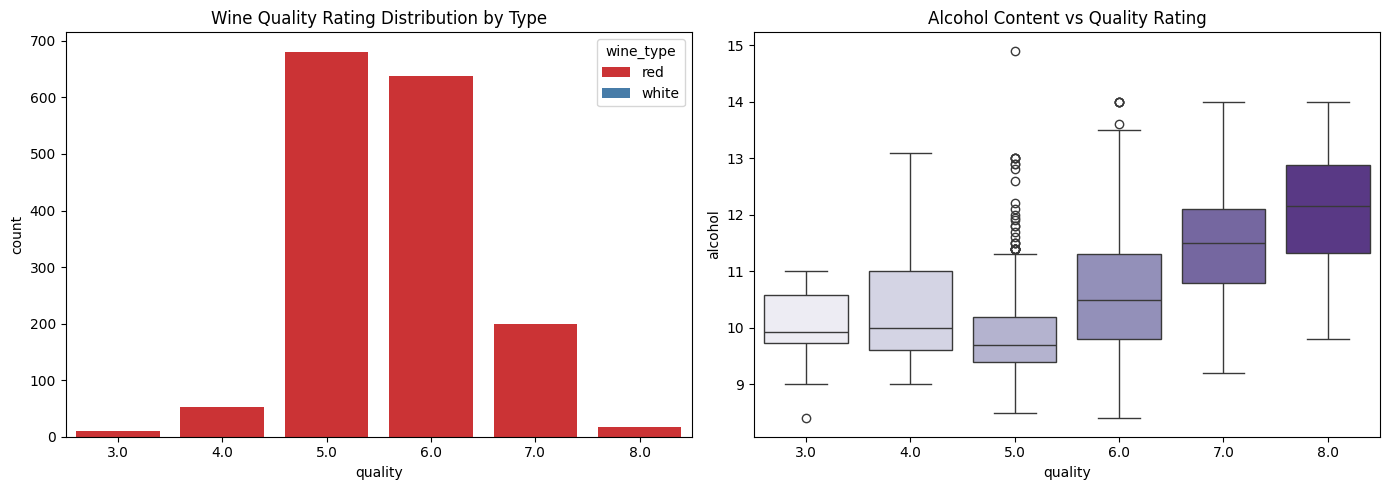

In [2]:
# --- 2. Target Quality Class Distribution ---
target_col = 'quality' if 'quality' in df.columns else df.columns[-2]

print('--- Raw Quality Score Counts ---')
print(df[target_col].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x=target_col, hue='wine_type', ax=axes[0], palette='Set1')
axes[0].set_title('Wine Quality Rating Distribution by Type')

# Alcohol vs Quality
sns.boxplot(data=df, x=target_col, y='alcohol', ax=axes[1], palette='Purples')
axes[1].set_title('Alcohol Content vs Quality Rating')

plt.tight_layout()
plt.show()

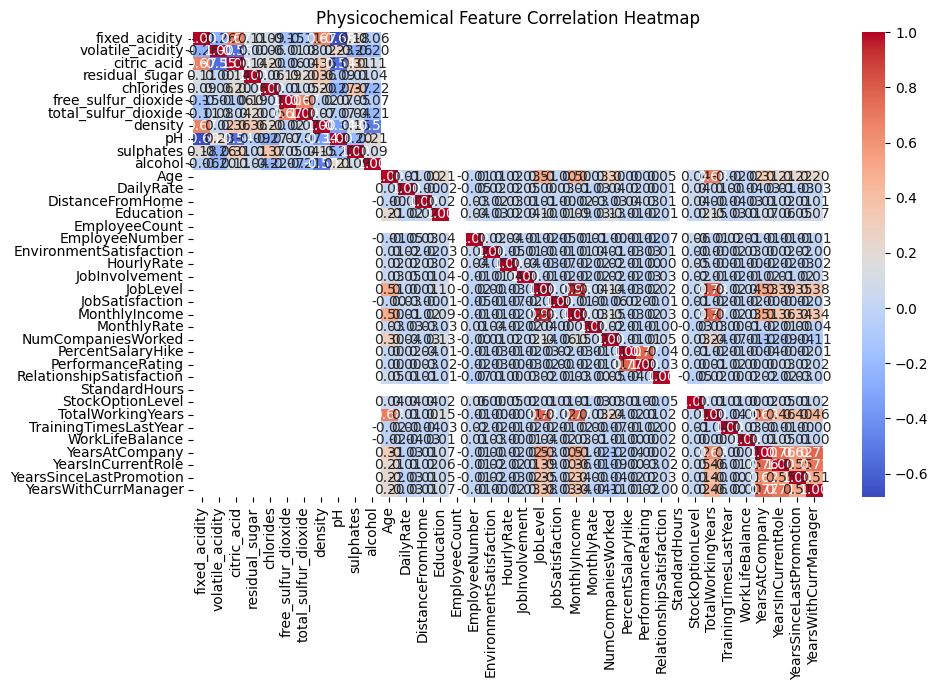

In [3]:
# --- 3. Physicochemical Feature Correlation Matrix ---
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Physicochemical Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [5]:
# --- 4. R3 Diagnostic Operating Window Computation ---
# Filter valid wine numeric columns and drop missing target rows
valid_wine_cols = [
    'fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
    'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
    'pH', 'sulphates', 'alcohol'
]

# Drop rows missing target or numerical feature values
df_clean = df.dropna(subset=[target_col] + [c for c in valid_wine_cols if c in df.columns]).copy()

# Binary classification: High Quality (>=6) vs Standard Quality (<6)
y = (df_clean[target_col].astype(float) >= 6).astype(int).values
X = df_clean[[c for c in valid_wine_cols if c in df_clean.columns]]

scaler = StandardScaler()
X_proc = scaler.fit_transform(X)

# 5-Fold Stratified Split for OOF Signals
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'LR': LogisticRegression(max_iter=1000),
    'XGB': HistGradientBoostingClassifier(),
    'MLP': MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=400, random_state=42)
}

oof_probs = {m: np.zeros((len(y), 2)) for m in models}

for train_idx, val_idx in skf.split(X_proc, y):
    X_tr, X_val = X_proc[train_idx], X_proc[val_idx]
    y_tr = y[train_idx]
    for name, model in models.items():
        model.fit(X_tr, y_tr)
        oof_probs[name][val_idx] = model.predict_proba(X_val)

# Compute Failure Vectors and R3 Diagnostics
accs, failures = {}, {}
for name in models:
    preds = np.argmax(oof_probs[name], axis=1)
    accs[name] = accuracy_score(y, preds)
    failures[name] = (preds != y).astype(int)

oracle_correct = np.any([failures[m] == 0 for m in models], axis=0)
acc_oracle = np.mean(oracle_correct)
best_static_acc = max(accs.values())
delta_oracle = acc_oracle - best_static_acc

rho_list = []
keys = list(models.keys())
for i in range(len(keys)):
    for j in range(i + 1, len(keys)):
        r_i, r_j = failures[keys[i]], failures[keys[j]]
        rho_list.append(np.corrcoef(r_i, r_j)[0, 1])

avg_rho = np.mean(rho_list)

print('==================================================')
print('     WINE QUALITY DATASET - R3 DIAGNOSTIC EVAL    ')
print('==================================================')
for m in models:
    print(f'Base Model Accuracy [{m}]: {accs[m]*100:.2f}%')
print(f'Best Static Model Acc     : {best_static_acc*100:.2f}%')
print(f'Oracle Upper Bound Acc    : {acc_oracle*100:.2f}%')
print(f'Oracle Headroom (Delta)   : {delta_oracle*100:.2f}%')
print(f'Pairwise Error Corr (rho) : {avg_rho:.3f}')
print('--------------------------------------------------')
if delta_oracle >= 0.03 and avg_rho <= 0.45:
    print('STATUS: PASS -> Wine Quality dataset is OPTIMAL for R3 Dynamic Routing')
else:
    print('STATUS: FAIL -> Static ensemble recommended')
print('==================================================')

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(


     WINE QUALITY DATASET - R3 DIAGNOSTIC EVAL    
Base Model Accuracy [LR]: 74.05%
Base Model Accuracy [XGB]: 80.80%
Base Model Accuracy [MLP]: 76.74%
Best Static Model Acc     : 80.80%
Oracle Upper Bound Acc    : 88.93%
Oracle Headroom (Delta)   : 8.13%
Pairwise Error Corr (rho) : 0.524
--------------------------------------------------
STATUS: FAIL -> Static ensemble recommended


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (400) reached and the optimization hasn't converged yet.
  warnings.warn(
